### Task Outline

Some hot Jupiters appear to be significantly larger than theoretical models  
predict. These “inflated” planets are typically very close to their host stars  
and receive intense stellar irradiation, but the physical mechanism responsible  
for their excess radii is still debated.

In this project, you could use the NASA Exoplanet Archive to select a sample of  
well-characterised transiting hot Jupiters. Retrieve their planetary radii,  
orbital periods, stellar properties, and equilibrium temperatures.


In [3]:
# Retrieving the necessary packages

import numpy as np
import matplotlib.pyplot as plt
import csv

In [112]:
# Setting up the data structure
data = []

# A function that will filter my data so that I only keep usable information
def to_float(value):
    try:
        return float(value)
    except:
        return None

with open("PSCompPars_2026(1485).csv", newline='') as file:
    for line in file:
        if not line.startswith("#"):  # Finds the first non-metadata line in my data file
            header_line = line # Stores the column names for reference
            break

    reader = csv.DictReader(file, fieldnames=header_line.strip().split(","))

    # A row here means all the data for one planet
    # This first part just cleans everything up
    for row in reader:
        temp = to_float(row["pl_eqt"])
        tperr = to_float(row["pl_eqterr1"])
        tnerr = to_float(row["pl_eqterr2"])
        radius = to_float(row["pl_radj"])
        rperr = to_float(row["pl_radjerr1"])
        rnerr = to_float(row["pl_radjerr2"])
        sma = to_float(row["pl_orbsmax"])
        smperr = to_float(row["pl_orbsmaxerr1"])
        smnerr = to_float(row["pl_orbsmaxerr2"])
        pl_mass = to_float(row["pl_bmassj"])
        pmperr = to_float(row["pl_bmassjerr1"])
        pmnerr = to_float(row["pl_bmassjerr2"])
        st_lum = to_float(row["st_lum"])
        slperr = to_float(row["st_lumerr1"])
        slnerr = to_float(row["st_lumerr2"])
        st_mass = to_float(row["st_mass"])
        smperr = to_float(row["st_masserr1"])
        smnerr = to_float(row["st_masserr2"])
        st_met = to_float(row["st_met"])
        smperr = to_float(row["st_meterr1"])
        smnerr = to_float(row["st_meterr2"])
        st_rad = to_float(row["st_rad"])
        srperr = to_float(row["st_raderr1"])
        srnerr = to_float(row["st_raderr2"])

        # Then, every planet that is missing data from a relevant column is excluded
        # The rest get stored one at a time as dictionaries in the list "data"
        if None not in (temp, tperr, tnerr, radius, rperr, rnerr, sma, smperr, smnerr, pl_mass, pmperr, pmnerr, st_lum, slperr, slnerr, st_mass, smperr, smnerr, st_met, smperr, smnerr, st_rad, srperr, srnerr):
            data.append({
                "pl_temp" : temp,
                "temp_plus" : tperr,
                "temp_minus" : tnerr,

                "pl_rad" : radius,
                "pl_rad_plus" : rperr,
                "pl_rad_minus" : rnerr,

                "sma" : sma,
                "sma_plus" : smperr,
                "sma_minus" : smnerr,

                "pl_mass" : pl_mass,
                "pm_plus" : pmperr,
                "pm_minus" : pmnerr,

                "st_lum" : st_lum,
                "lum_plus" : slperr,
                "lum_minus" : slnerr,

                "st_mass" : st_mass,
                "mass_plus" : smperr,
                "mass_minus" : smnerr,

                "st_met" : st_met,
                "met_plus" : smperr,
                "met_minus" : smnerr,

                "st_rad" : st_rad,
                "st_rad_plus" : srperr,
                "st_rad_minus" : srnerr
            })

        # I later had one outlier that made a graph less meaningful, so this removes it pre-emptively
        for d in data:
            if d["st_lum"] / (4 * np.pi * d["sma"] ** 2) < -1000:
                data.remove(d)


## Observed Data
# Putting all of the raw data from the data base into lists for graphing

temps = [d["pl_temp"] for d in data]
temps_plus = [d["temp_plus"] for d in data]
temps_minus = [abs(d["temp_minus"]) for d in data]

radii = [d["pl_rad"] for d in data]
radii_plus = [d["pl_rad_plus"] for d in data]
radii_minus = [abs(d["pl_rad_minus"]) for d in data]

smas = [d["sma"] for d in data]
smas_plus = [d["sma_plus"] for d in data]
smas_minus = [abs(d["sma_minus"]) for d in data]

pl_masses = [d["pl_mass"] for d in data]
pl_masses_plus = [d["pm_plus"] for d in data]
pl_masses_minus = [d["pm_minus"] for d in data]

lums = [d["st_lum"] for d in data]
lums_plus = [d["lum_plus"] for d in data]
lums_minus = [abs(d["lum_minus"]) for d in data]

st_masses = [d["st_mass"] for d in data]
masses_plus = [d["mass_plus"] for d in data]
masses_minus = [abs(d["mass_minus"]) for d in data]

st_mets = [d["st_met"] for d in data]
mets_plus = [d["met_plus"] for d in data]
mets_minus = [abs(d["met_minus"]) for d in data]

st_rads = [d["st_rad"] for d in data]
srads_plus = [d["st_rad_plus"] for d in data]
srads_minus = [abs(d["st_rad_minus"]) for d in data]

## Calculated Information from Observed Data

fluxes = [
    d["st_lum"] / (4 * np.pi * d["sma"] ** 2)
    for d in data
]

percentage_increase = [
    ((d["pl_rad"] / ((1.1 * d["pl_temp"] ** 0.35) / 11)) -1) * 100
    for d in data
]


---
Make a plot of planetary radius as a function of equilibrium temperature and  
investigate whether there is a clear transition where inflation becomes significant.

In [76]:
# Some basic Jupiter data and a function that plots Jupiter on the graph for reference
# At the moment, this only works for my Temperature-Radius plots

J_temp = 122
J_rad = 1

def Jupiter():
    plt.scatter(J_temp, J_rad, color="green", s=12, label="Jupiter")

In [96]:
# This function plots three lines of best fit for different sections of the graph,
# This only works for my Temperature-Radius plots

def Fit_lines(xax, yax):
    low_x = []
    low_y = []
    mid_x = []
    mid_y = []
    high_x = []
    high_y = []

    for x, y in zip(xax, yax):
        if x <= 1200:
            low_x.append(x)
            low_y.append(y)
        elif x <= 1800:
            mid_x.append(x)
            mid_y.append(y)
        elif x <= 4000:
            high_x.append(x)
            high_y.append(y)

    m2, b2 = np.polyfit(low_x, low_y, 1)
    m3, b3 = np.polyfit(mid_x, mid_y, 1)
    m4, b4 = np.polyfit(high_x, high_y, 1)

    x2 = np.linspace(min(low_x), max(low_x), 100)
    y2 = m2 * x2 + b2
    plt.plot(x2, y2, linestyle="-", color="red", label="Cool Fit")

    x3 = np.linspace(min(mid_x), max(mid_x), 100)
    y3 = m3 * x3 + b3
    plt.plot(x3, y3, linestyle="-", color="orange", label="Warm Fit")

    x4 = np.linspace(min(high_x), max(high_x), 100)
    y4 = m4 * x4 + b4
    plt.plot(x4, y4, linestyle="-", color="yellow", label="Hot Fit")

In [97]:
def plot_legend(xaxis, yaxis, xname, yname, Jup, Fits, n):
    plt.figure(figsize=(12,8)) # Size of the plot, for visibility of data
    plt.scatter(xaxis, yaxis, s=10, label="Hot Jupiter") # Scatter plot to view individual data points, not joined by a line

    if Jup == True: # Toggle for Jupiter
        Jupiter()

    if Fits == True: # Toggle for lines of best fit
        Fit_lines(xaxis, yaxis)

    plt.xlabel(xname) # Labels the independent variable on the x-axis
    plt.ylabel(yname) # Labels the dependent variable on the y-axis
    plt.title(f"Figure {n}") # Simple graph title

    plt.legend() # Displays a legend for clarity
    plt.show() # Displays the fully constructed graph

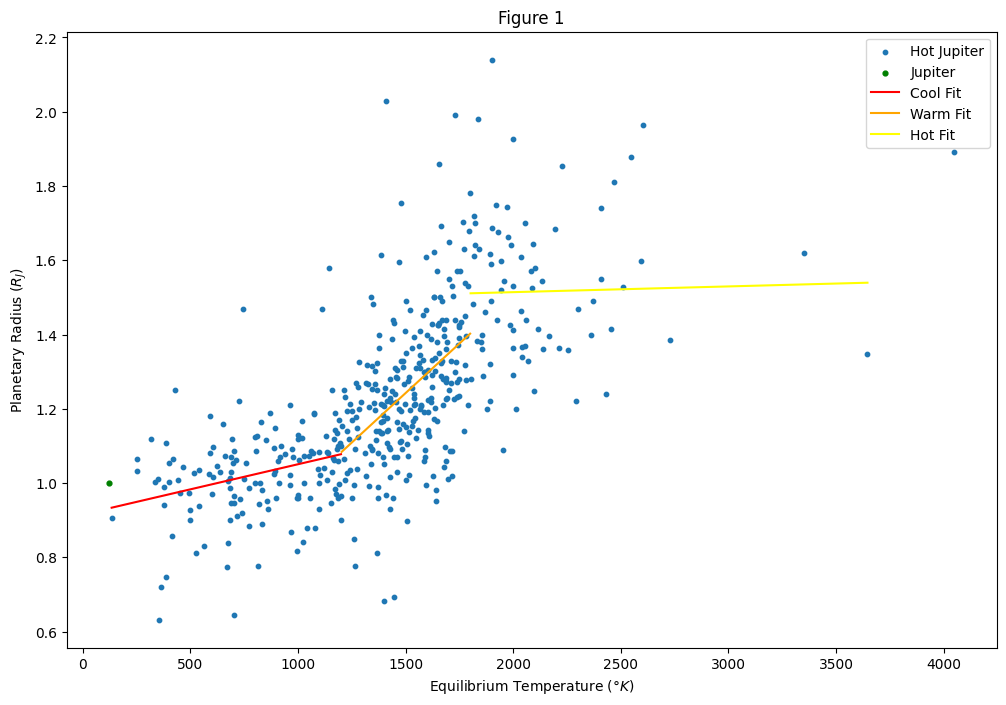

In [125]:
plot_legend(temps, radii, "Equilibrium Temperature ($°K$)", "Planetary Radius ($R_{J}$)", True, True, 1)

# Whatever is between $ symbols uses LaTex formatting, here it's for the subscript

##### `Jup == True`

Just eye-balling the graph we can see that the temperature has little effect on  
radius until around 1200°K. 

From there the data shows a stronger correlation around a noticeable increase  
in radius until the temperature reaches around 1800°K. 

We not only have much less data for planets hotter than this, but the data we  
do have shows extremely weak correlation. 

##### `Fits == True`

By breaking up a line of best fit into three segments, we see very clearly that  
radius is related to temperature for a certain range of temperatures.

---
How does the degree of inflation depend on incident flux?

In [71]:
def base_plot(xaxis, yaxis, xname, yname, a): # A slightly simpler plotting function for the next few graphs
    plt.figure(figsize=(12,8))
    plt.scatter(xaxis, yaxis, s=10)

    plt.xlabel(xname)
    plt.ylabel(yname)
    plt.title(f"Figure {a}")

    plt.show()


<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\macau\AppData\Local\Temp\ipykernel_24696\419007785.py:1: SyntaxWarning: invalid escape sequence '\c'
  base_plot(fluxes, percentage_increase, "Incidence Flux ($erg \cdot cm^{-2} \cdot s^{-1}$)", "Degree of Inflation from Expected Value (%)", 2)


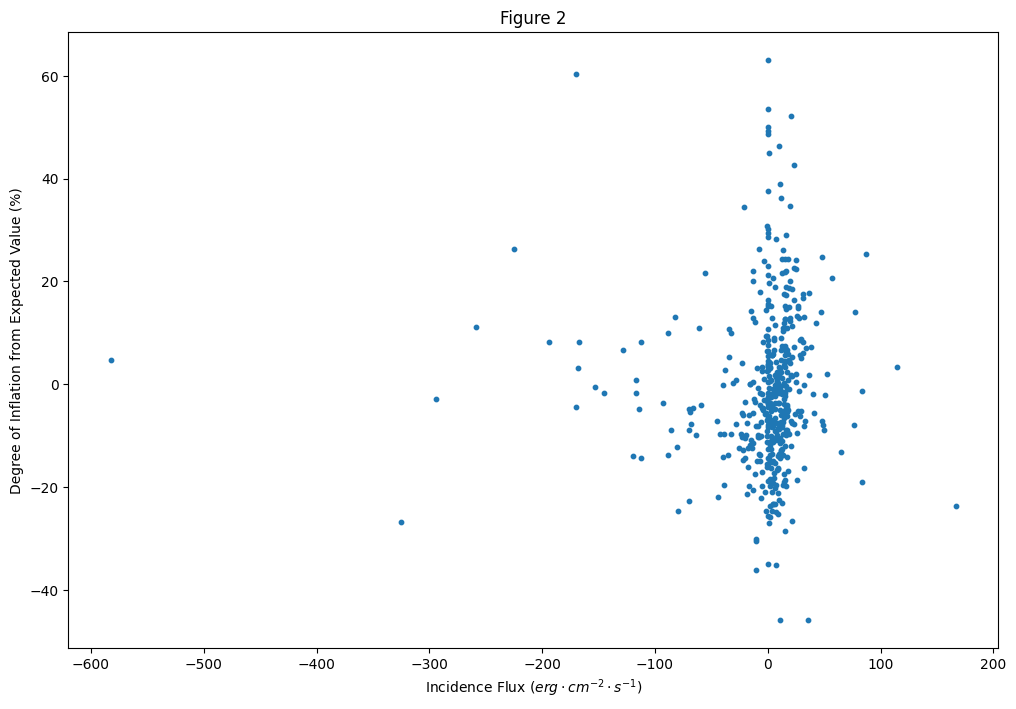

In [115]:
base_plot(fluxes, percentage_increase, "Incidence Flux ($erg \cdot cm^{-2} \cdot s^{-1}$)", "Degree of Inflation from Expected Value (%)", 2)

# The warnings haven't caused me any problems, so I've just ignored them

Even having removed the outlier at -1000 Incidence Flux, this graph is still  
relatively bunched up. This is because flux depends on the luminosity of the  
host star, and that data was given relative to our Sun by the logarithmic scale  
in base 10.

So, Figure 2 tells us that most of our hot jupiter host stars have similar  
luminosity to our Sun.

And with greater relevance to this project, it's quite clear that luminosity  
doesn't have any influence on the inflation of hot jupiters since for stars  
with very similar luminosities, some hot jupiters are up to 40% smaller, while  
others are up to 60% larger.

---
Are there correlations with host star properties such as mass or metallicity?

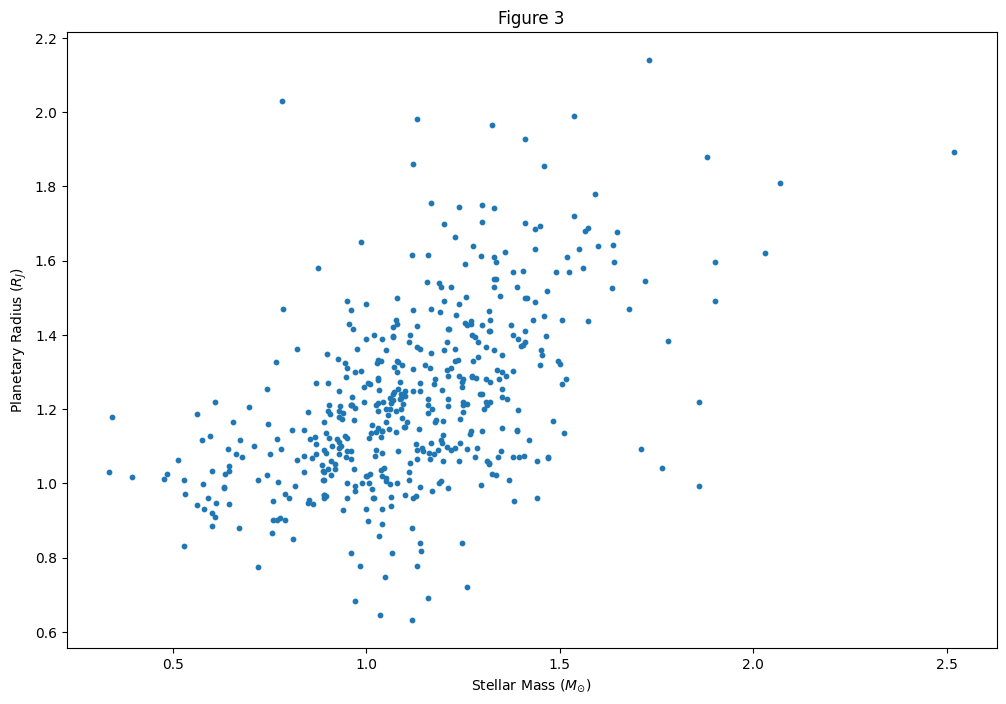

In [107]:
base_plot(st_masses, radii, "Stellar Mass ($M_{⊙}$)", "Planetary Radius ($R_{J}$)", 3)

This plot shows very weak correlation between Stellar Mass and Planetary Radius  
other than perhaps the slightest positively proportional trend.

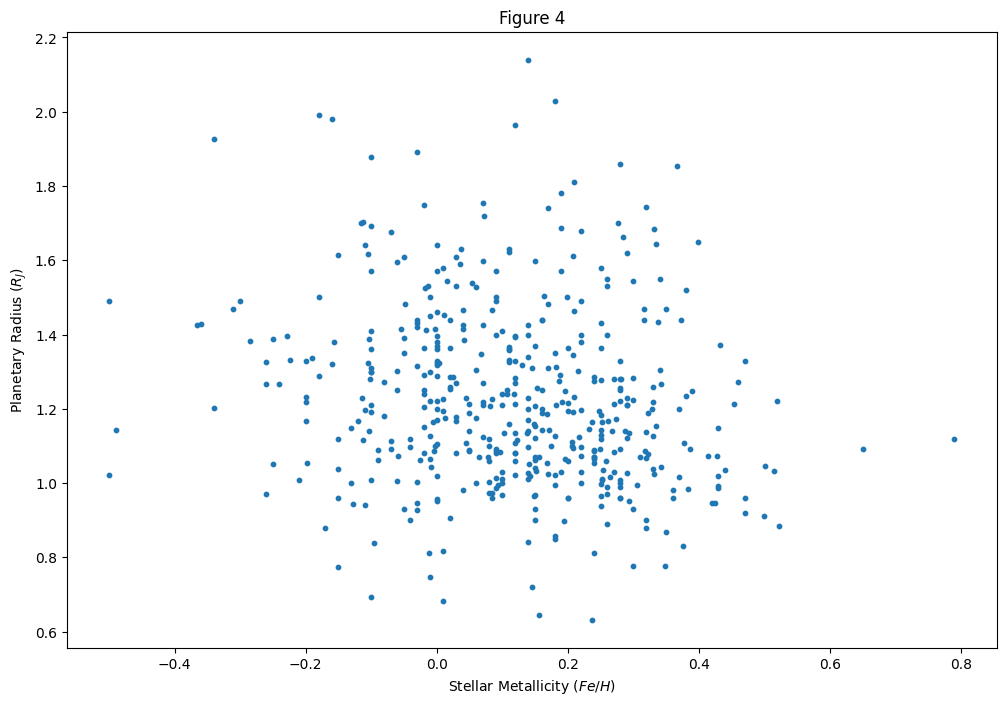

In [105]:
base_plot(st_mets, radii, "Stellar Metallicity ($Fe/H$)", "Planetary Radius ($R_{J}$)", 4)

Like luminosity, Stellar Metallicity is given in log base 10, so a 1 on the  
x-axis would mean the star is 10 times more metal-rich than our Sun.

This plot shows that there is even less correlation between Stellar Metallicity  
and Planetary Radius. So, clearly, these are unrelated variables.

---
How large are the observational uncertainties, and how do they affect your conclusions?

In [55]:
def error_plot(xaxis, yaxis, xname, yname, xerr, yerr, n):
    plt.figure(figsize=(12,8))

    # Mostly similar in appearance to a scatter plot, but now I can show error bars
    plt.errorbar(x=xaxis, y=yaxis,
                 xerr=xerr, yerr=yerr,
                 fmt="o", markersize=4, capsize=3)

    plt.xlabel(xname)
    plt.ylabel(yname)
    plt.title(f"Figure {n}")

    plt.show()

In [126]:
# Combining upper and lower limits into one array for each variable
# "terr" meaning temperature error, our x-axis
# "prerr" meaning planet radius error, our y-axis

terr = [temps_minus, temps_plus]
prerr = [radii_minus, radii_plus]

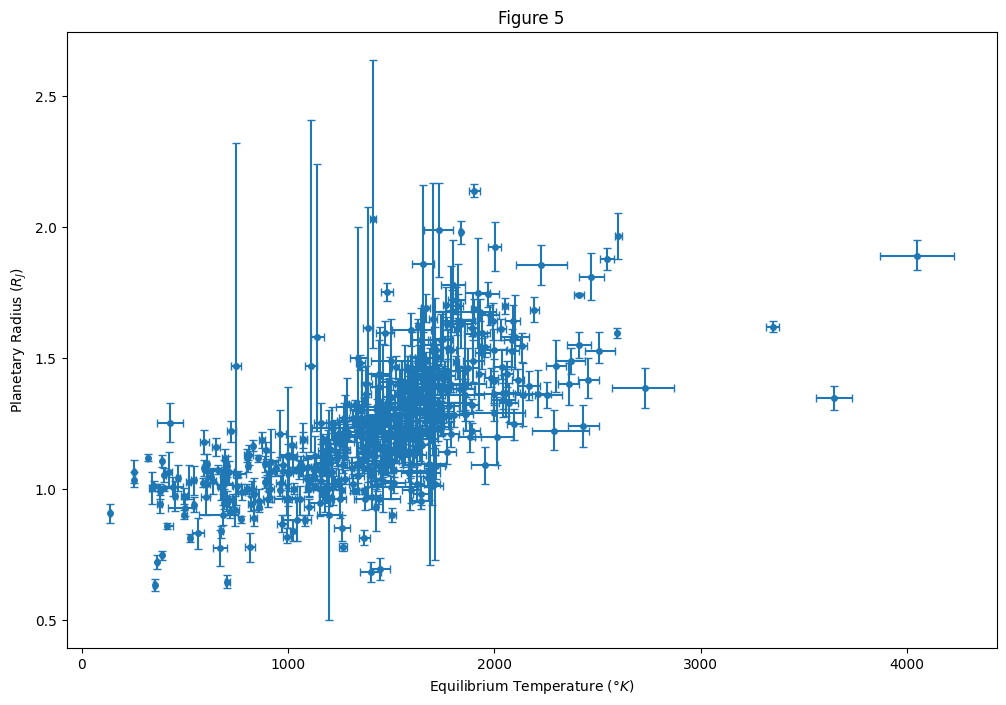

In [129]:
# This function has nice versatility in that it can plot errors in just one axis, or both at once by using the "None" value in the place of one error array.

error_plot(temps, radii, "Equilibrium Temperature ($°K$)", "Planetary Radius ($R_{J}$)", terr, prerr, 5)

##### `None, prerr`

Some data points have extremely large uncertainties, which could have a minor  
impact on the overall conclusions, but the vast majority of uncertainties are  
much more reasonable. And, for all of the points with large uncertainties, the  
range includes the possibility of placing them within the main body of data,  
which would only serve to strengthen the correlation already present.

We could even remove or ignore the unreliable data points and the plot would  
convey the same information.

##### `terr, None`

While the number themselves are bigger, the uncertainties in the temperatures  
are significantly less impactful to the overall trend.

##### `terr, prerr`

This doesn't give us new information, but it's nice to have it.

---
Compare your results to simple theoretical expectations for gas giant structure.

In [122]:
# A function that plots a model I found while doing some research that is interesting and informative to compare to

def Edmonson_Et_al(xax):
    x1 = np.linspace(min(xax), max(xax), 100)
    y1 = (1.1 * x1 ** 0.35) / 11 # I divide by 11 to convert from the units of Earth Radius used in the paper to units of Jupiter Radius for this project
    plt.plot(x1, y1, linestyle="-", color="black", label="Edmonson Et al. (2023)")

In [123]:
# The ultimate function that combines the original legend plot with error bars,
# and utilises the modularity of little functions to be a bit more concise.
# Each of the sub-functions can be "switched" on or off through the use of booleans.
# The main downside is the absurd amount of information required for the function
# to operate every time you want to call it.

def legend_error_plot(xaxis, yaxis, xname, yname, xerr, yerr, Jup, Ed, Fits, n):
    plt.figure(figsize=(12,8))
    plt.errorbar(x=xaxis, y=yaxis,
                 xerr=xerr, yerr=yerr,
                 fmt="o", markersize=4, capsize=3, label='"Hot Jupiter"')

    if Jup == True:
        Jupiter()

    if Ed == True:
        Edmonson_Et_al(xaxis)

    if Fits == True:
        Fit_lines(xaxis, yaxis)

    plt.xlabel(xname)
    plt.ylabel(yname)
    plt.title(f"Figure {n}")

    plt.legend()
    plt.show()

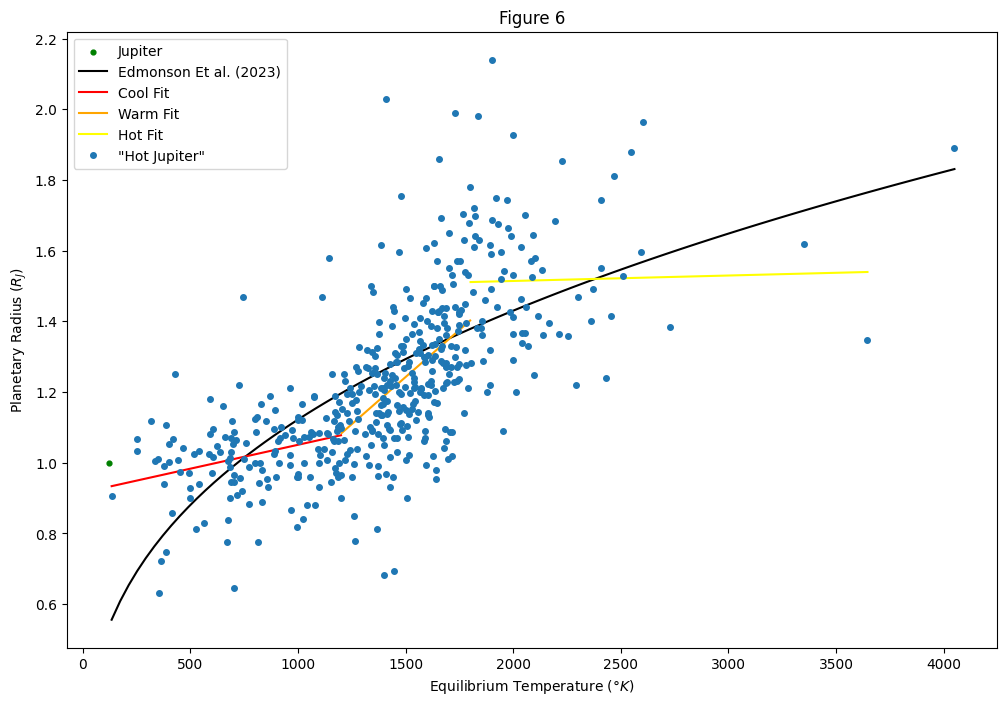

In [124]:
legend_error_plot(temps, radii, "Equilibrium Temperature ($°K$)", "Planetary Radius ($R_{J}$)", None, None, True, True, True, 6)

##### Edmonson, Et al. (2023)

Edmondson, K., Norris, J., & Kerins, E. (2023). BREAKING UP WITH THE CONTINUOUS  
EXOPLANET MASS-RADIUS RELATION. arXiv. https://doi.org/10.48550/arXiv.2310.16733  

Their paper had a broader scope than this project, covering rocky, neptunian,  
and jovian planets, but it also used the NASA Exoplanet Archive for data. This  
model was an attempt at more accurately predicting radii for jovian planets,  
rather than all kinds of planets. The main point of significance for this  
project is the fact that for jovian planets (>115 $M_{⊕}$ or >0.36 $M_{J}$​),  
radius only depends on temperature, not mass.  

The model fits somewhat well in the 750 $°K$ - 1750 $°K$  range of data, but  
extends beyond the scope of the data I have.  

Strangely, while their model is concave down, the data I see seems to suggest  
that a concave up model would be more accurate.

---
What do your findings suggest about the physical processes operating in these atmospheres?

It is clear that between equilibrium temperatures of around  
1200 $°K$ - 1800 $°K$, radius increases, but the Edmonson, Et al. model fits  
that data fairly well, so it may not be true that these planets have  
particularly inflated radii.

So, the physical processes in the atmospheres of these hot jupiters seem to be  
operating as they can be expected to, according to the Edmonson, Et al. model.